In [1]:
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme()

In [3]:
wa=pd.read_csv("wannoreport2.csv")


In [4]:
realscores={0:8.5,
 1:7,
 2:7,
 3:6,
 4:8.5,
 5:6,
 6:7}

In [5]:
wa['Actual']=wa['Unnamed: 0'].map(realscores)
wa['AbsError']=abs(wa['Actual']-wa['score'])


Text(0.5, 1.0, 'Score Error Distribution By Model')

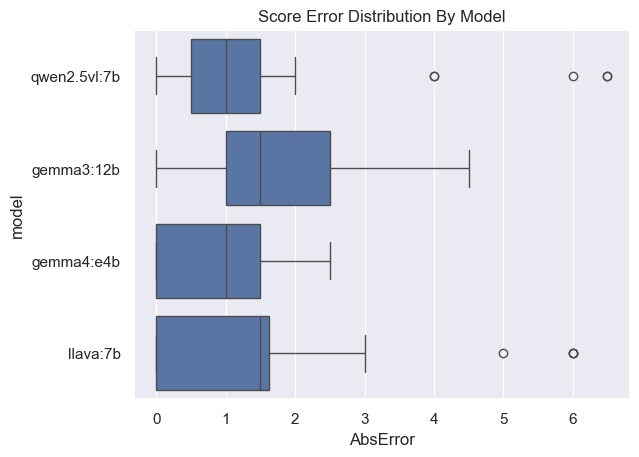

In [6]:
sns.boxplot(y='model',x='AbsError',data=wa).\
    set_title('Score Error Distribution By Model')

Text(0.5, 1.0, 'Scoring Duration Distribution By Model')

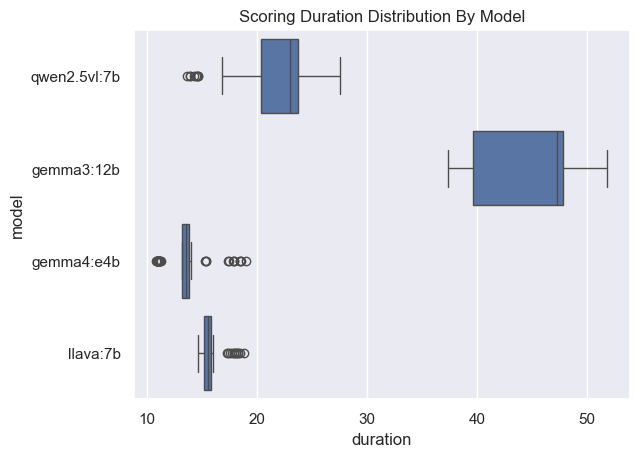

In [7]:
sns.boxplot(y='model',x='duration',data=wa).\
    set_title('Scoring Duration Distribution By Model')

Text(0.5, 1.0, 'Score Error Distribution By Prompt')

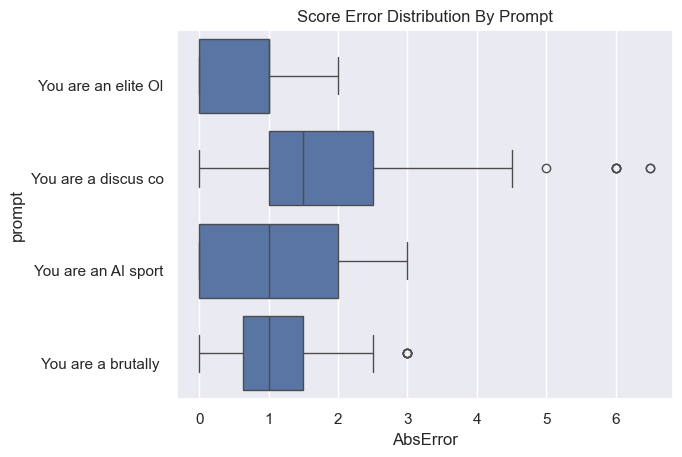

In [8]:
sns.boxplot(y='prompt',x='AbsError',data=wa).\
    set_title('Score Error Distribution By Prompt')

Text(0.5, 1.0, 'Score Error Distribution By Frames')

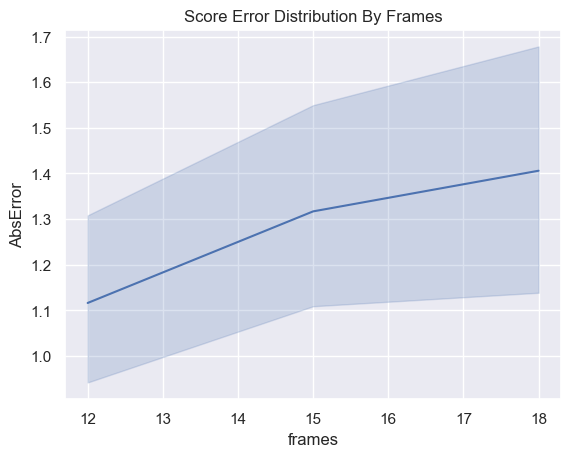

In [9]:
sns.lineplot(y='AbsError',x='frames',data=wa).\
    set_title('Score Error Distribution By Frames')

In [10]:
wa.groupby(['prompt','frames','model'])['AbsError'].median().sort_values().head(10)

prompt                 frames  model       
\nYou are an elite Ol  18      gemma3:12b      0.50
                       12      gemma3:12b      0.50
\nYou are a discus co  12      qwen2.5vl:7b    0.50
\nYou are a brutally   15      qwen2.5vl:7b    0.75
\nYou are an elite Ol  15      gemma3:12b      1.00
                       12      qwen2.5vl:7b    1.00
\nYou are a discus co  18      gemma4:e4b      1.00
\nYou are an elite Ol  12      llava:7b        1.00
                       18      llava:7b        1.00
                               qwen2.5vl:7b    1.00
Name: AbsError, dtype: float64

In [11]:
wa.groupby(['prompt','frames','model'])['AbsError'].mean().sort_values().head(10)

prompt                 frames  model       
\nYou are an elite Ol  12      gemma3:12b      0.428571
                       18      gemma3:12b      0.571429
\nYou are a discus co  12      qwen2.5vl:7b    0.571429
\nYou are an AI sport  18      gemma4:e4b      0.714286
                       15      gemma4:e4b      0.714286
                       12      qwen2.5vl:7b    0.714286
                               gemma4:e4b      0.714286
\nYou are an elite Ol  18      llava:7b        0.714286
                       12      gemma4:e4b      0.714286
                               llava:7b        0.714286
Name: AbsError, dtype: float64

In [12]:
wa.groupby(['model','prompt',"frames"])['AbsError'].\
    describe()[['25%','50%','75%']].\
    sort_values('50%').head(5)

,,,25%,50%,75%
model,prompt,frames,,,
gemma3:12b,\nYou are an elite Ol,12,0.000,0.50,0.750
qwen2.5vl:7b,\nYou are a discus co,12,0.000,0.50,1.000
gemma3:12b,\nYou are an elite Ol,18,0.250,0.50,1.000
qwen2.5vl:7b,\nYou are a brutally,15,0.375,0.75,1.125
gemma4:e4b,\nYou are an elite Ol,15,0.000,1.00,1.250


In [16]:
wa['framepercent']=(wa['frames']/wa['fileframes'])

# Is there room to optimize frame counts based on file size?

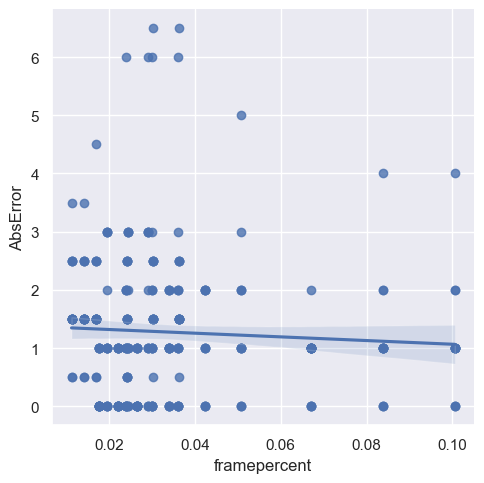

In [20]:
sns.lmplot(data=wa, x="framepercent", y="AbsError")

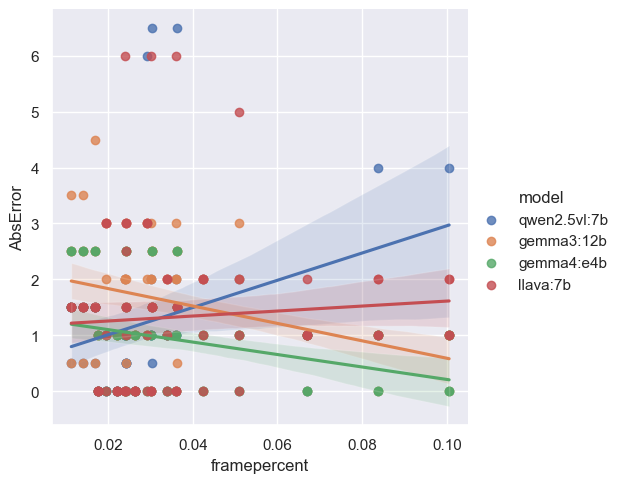

In [19]:
sns.lmplot(data=wa, x="framepercent", y="AbsError",hue='model')

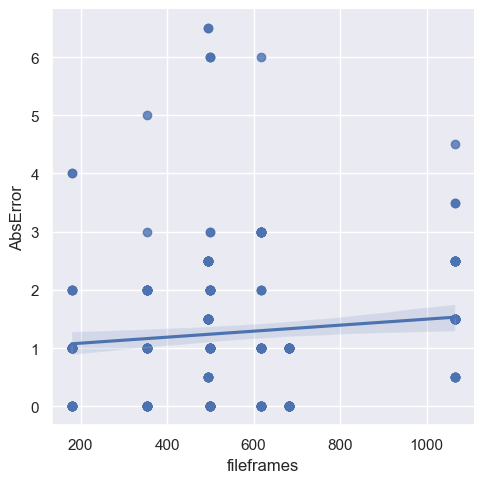

In [18]:
sns.lmplot(data=wa, x="fileframes", y="AbsError")

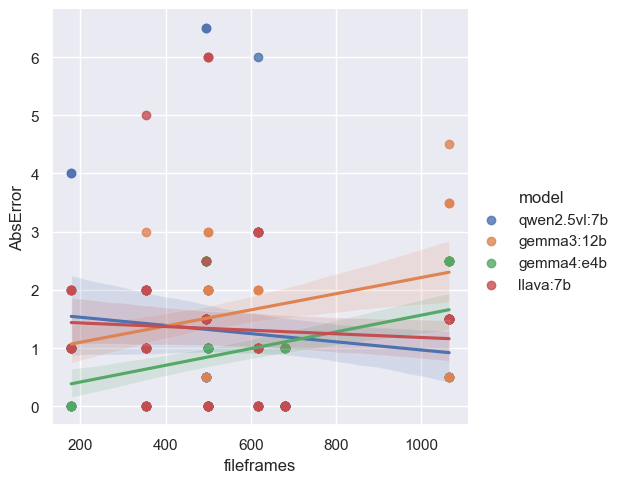

In [23]:
sns.lmplot(data=wa, x="fileframes", y="AbsError",hue='model')